# Lab 3: Pretrained Transformers
  [![View notebooks on Github](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=View%20On%20Github&color=lightgrey)](https://github.com/cltl/nlp_transformer_tutorials/blob/main/NLP_Lab3_Pretrained_Transformers.ipynb)
 [![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cltl/nlp_transformer_tutorials/blob/main/NLP_Lab3_Pretrained_Transformers.ipynb)


- This notebook is part of the NLP course for the Master's AI. In the previous labs, we explored what transformers do at a high level (Lab 1) and built one from scratch (Lab 2). In this lab, we shift perspective: instead of building the engine, we learn to drive it.
- We will work with pretrained models from the [HuggingFace `transformers`](https://huggingface.co/docs/transformers/) library, which is the standard tool for loading and using transformer models in practice.

---

This notebook covers three topics:

1.  **Text generation and chat models** : We load a small causal language model, explore generation strategies, and look under the hood of chat/instruct models to see that they are just next-token prediction with structured prompts.
2.  **BERT for sentiment classification** : We fine-tune an encoder-only transformer (BERT) on a classification task, contrasting its bidirectional attention with the causal attention from Labs 1–2.
3.  **The logit lens** : We peek inside a model during inference to see what intermediate layers are "thinking," reproducing a simplified version of a result from recent research.


**Note for Running on Colab** If you're running this in Google Colab, make sure to use the GPU.
- Click the arrow on the right top, next to "RAM and DISK"
- Select "Change Runtime Type" -> Click `T4 GPU`

## Content & Learning Objectives

> ##### Learning Objectives
>
> - Load and use pretrained transformer models from HuggingFace
> - Understand the difference between base models and instruction-tuned models
> - Understand how chat templates work and why they are just next-token prediction
> - Fine-tune BERT for a downstream classification task
> - Contrast bidirectional (BERT) and causal (GPT) attention
> - Apply the logit lens to inspect a model's intermediate representations


### Install Env

In [ ]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules

# Install dependencies
try:
    import bertviz
except ImportError:
    %pip install -q bertviz

# Clone the course repo (only needed in Colab)
if IN_COLAB:
    repo_url = "https://github.com/cltl/nlp_transformer_tutorials.git"
    repo_dir = "/content/nlp_transformer_tutorials"
    if not os.path.exists(repo_dir):
        !git clone {repo_url} {repo_dir}
    os.chdir(repo_dir)

# Make sure the repo root is on the Python path so `import utils.tests_part2` works
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())


### Load Packages

In [ ]:
import os
import sys

import gc
import numpy as np
import pandas as pd
import torch as t
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm

from IPython.display import display, HTML
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    BertModel,
    TrainingArguments,
    Trainer,
)

device = t.device("mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


---

# Part A: Decoder - Text Generation and Chat Models

In Lab 1 we saw that a transformer predicts the next token given all previous tokens. In Lab 2 we built this mechanism from scratch and implemented greedy decoding and temperature sampling. Here we revisit text generation using HuggingFace's `generate()` API, which wraps all of these strategies (and more) into a single function call.

More importantly, we will look at what makes a "chat model" different from a base model,  and see that the answer is less magical than it might seem.


## Loading a base language model

We use [Qwen2.5-0.5B](https://huggingface.co/Qwen/Qwen2.5-0.5B), a small (0.5 billion parameter) causal language model. This is a **base model**: it was trained on next-token prediction over a large text corpus, but it has not been fine-tuned to follow instructions or hold conversations.

- The first time you use it, the model will be downloaded, which is about 1GB, and might take about 1 minute on avg (or a few minutes if your internet connection is bad)


In [ ]:
base_model_name = "Qwen/Qwen2.5-0.5B"
base_tokenizer = AutoTokenizer.from_pretrained(base_model_name)
base_model = AutoModelForCausalLM.from_pretrained(base_model_name, torch_dtype=t.float32).to(device)
base_model.eval()
print(f"Loaded {base_model_name} with {sum(p.numel() for p in base_model.parameters()) / 1e6:.0f}M parameters")


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded Qwen/Qwen2.5-0.5B with 494M parameters


Let's generate some text. The `model.generate()` function takes token IDs and produces a continuation. By default it uses greedy decoding (always picking the most likely token), just like we implemented in Lab 2.


In [ ]:
prompt = "The capital of the Netherlands is"
inputs = base_tokenizer(prompt, return_tensors="pt").to(device)

output_ids = base_model.generate(**inputs, max_new_tokens=50, do_sample=False)
print("=== Greedy decoding ===")
print(base_tokenizer.decode(output_ids[0], skip_special_tokens=True))


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


=== Greedy decoding ===
The capital of the Netherlands is ____
A. Amsterdam
B. Rotterdam
C. Rotterdam
D. Amsterdam
Answer:
A

Which of the following statements about the geographical characteristics of the four countries is incorrect?
A. Country A has a temperate oceanic climate.



### Sampling strategies

In Lab 2, we implemented temperature sampling. HuggingFace's `generate()` supports this and other strategies via simple keyword arguments. Here is a brief overview:

- **Greedy** (`do_sample=False`): always pick the highest-probability token. Deterministic but can be repetitive.
- **Temperature** (`temperature=0.7`): divide logits by temperature before softmax, then sample. Lower = more confident, higher = more random.
- **Top-k** (`top_k=50`): only sample from the top-k most likely tokens.
- **Top-p / nucleus** (`top_p=0.9`): only sample from the smallest set of tokens whose cumulative probability exceeds p.

These can be combined. In practice, most applications use temperature + top-p together.


In [ ]:
# Temperature sampling
output_ids = base_model.generate(**inputs, max_new_tokens=50, do_sample=True, temperature=0.7, top_p=0.9)
print("=== Temperature 0.7 + top-p 0.9 ===")
print(base_tokenizer.decode(output_ids[0], skip_special_tokens=True))
print()

# Higher temperature = more random
output_ids = base_model.generate(**inputs, max_new_tokens=50, do_sample=True, temperature=1.5, top_p=0.9)
print("=== Temperature 1.5 + top-p 0.9 ===")
print(base_tokenizer.decode(output_ids[0], skip_special_tokens=True))


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


=== Temperature 0.7 + top-p 0.9 ===
The capital of the Netherlands is the world-famous city of Amsterdam. Amsterdam is a cosmopolitan city with a long history. It was founded by the Dutch in the 15th century. Amsterdam was the capital of the Netherlands from 1584 until 17

=== Temperature 1.5 + top-p 0.9 ===
The capital of the Netherlands is known worldwide because it has many ancient Roman landmarks, but what does that tell us about this island country's history and how do they survive despite being underwater?
The United Kingdom is currently underwater.
The island country was formed as the result of the split of


## Loading the instruction-tuned version

Now we load the **instruction-tuned** (or "chat") version of the same base model. This model was further trained (via supervised fine-tuning and/or RLHF) to follow instructions and hold conversations.

The key insight is that the architecture is identical, the only difference is the training data and procedure.


In [ ]:
chat_model_name = "Qwen/Qwen2.5-0.5B-Instruct"
chat_tokenizer = AutoTokenizer.from_pretrained(chat_model_name)
chat_model = AutoModelForCausalLM.from_pretrained(chat_model_name, torch_dtype=t.float32).to(device)
chat_model.eval()
print(f"Loaded {chat_model_name}")


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded Qwen/Qwen2.5-0.5B-Instruct


## What is a chat template?

Chat models expect input in a specific format that marks system messages, user turns, and assistant turns using special tokens. The `tokenizer.apply_chat_template()` method converts a list of messages into this format.

Let's look at what it actually produces, the "magic" behind chat models is just structured text formatting:


In [ ]:
messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "What is the capital of the Netherlands?"},
]

# Convert to the model's expected format, as a readable string
formatted = chat_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print("=== Formatted chat template (raw text) ===")
print(repr(formatted))
print()
print("=== Formatted chat template (readable) ===")
print(formatted)


=== Formatted chat template (raw text) ===
'<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nWhat is the capital of the Netherlands?<|im_end|>\n<|im_start|>assistant\n'

=== Formatted chat template (readable) ===
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is the capital of the Netherlands?<|im_end|>
<|im_start|>assistant



As you can see, the chat template is just a structured string with special tokens (like `<|im_start|>` and `<|im_end|>`) that delimit the different roles. The model was trained on text formatted exactly like this, so it knows to continue generating as the "assistant."

This is the core insight: **a chat model is just a next-token predictor that was trained on data formatted with these special tokens.** There is no separate "chat mechanism", it's all the same autoregressive generation from Lab 1.


### Special tokens are single tokens

The special tokens like `<|im_start|>` and `<|im_end|>` might look like multi-character strings, but each one is actually a **single token** in the vocabulary with its own unique ID. Let's verify by looking at the token IDs produced by `apply_chat_template`:


In [ ]:
from utils.utils_part3 import show_tokens, color_label_table

In [ ]:
message_str = chat_tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
print(message_str)
show_tokens(message_str, chat_tokenizer)

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is the capital of the Netherlands?<|im_end|>
<|im_start|>assistant



## Comparing base and instruct models

Let's feed the same chat-formatted prompt to both models and see what happens. The instruct model was trained on this format, so it should produce a coherent response. The base model was not, so its output will likely be different, it may try to continue the pattern as if it were generic text.


In [ ]:
# Tokenize the chat-formatted prompt
chat_inputs = chat_tokenizer(formatted, return_tensors="pt").to(device)

# Generate with the instruct model
output_ids = chat_model.generate(**chat_inputs, max_new_tokens=50, do_sample=True, temperature=0.7, top_p=0.9)
response = chat_tokenizer.decode(output_ids[0], skip_special_tokens=False)
print("=== Instruct model response ===")
print(response)


=== Instruct model response ===
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is the capital of the Netherlands?<|im_end|>
<|im_start|>assistant
The capital city of the Netherlands is Amsterdam.<|im_end|>


In [ ]:
# Now feed the exact same chat-formatted input to the base model.
# We use the chat_tokenizer since it contains the special tokens.
# The base model hasn't seen this format during training.
base_inputs = chat_tokenizer(formatted, return_tensors="pt").to(device)

# output_ids = base_model.generate(**base_inputs, max_new_tokens=100, do_sample=False)
output_ids = base_model.generate(**base_inputs, max_new_tokens=50, do_sample=True, temperature=0.7, top_p=0.9)
response = chat_tokenizer.decode(output_ids[0], skip_special_tokens=False)
print("=== Base model response (same chat-formatted input) ===")
print(response)


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


=== Base model response (same chat-formatted input) ===
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is the capital of the Netherlands?<|im_end|>
<|im_start|>assistant
ratulations!<|endoftext|>


You should notice that:

- The **instruct model** produces a focused, helpful answer because it was specifically trained on this chat format.
  - Usually answers the question correctly (for simple questions)
  - Also stops generation after the the question has been answered.
    - Note: the reason this happends is due to several factors, firstly it more consistently generates the end of turn token <|im_end|>. Secondly, the model's pipeline has been set up so that if this token is generated, we won't ask the model for any more new tokens.
- The **base model** may produce something that looks partially coherent (because it has seen some similar patterns in its training data), but the output tends to be noisier, less focused, and may not actually answer the question. It might:
  - Continue generating more "user/assistant" turns
  - Drift into unrelated text.
  - Provide harmful answers.
  - Add weird random artifacts such as emojis, or might even answer in other languages sometimes.

This illustrates why instruction tuning matters: same architecture, same prompt format, but very different behavior because of different training.


## Zero-shot and few-shot classification

Before we move on to fine-tuning BERT, let's see how well the instruct model can classify sentiment **without any training at all**. This is the key advantage of instruction-tuned models: we can get them to perform tasks just by describing the task in natural language.

- **Zero-shot**: We simply ask the model to classify a sentence with no examples.
- **Few-shot**: We provide a handful of labeled examples in the prompt to help the model understand the expected format and task.

We'll evaluate on a subset of the SST-2 validation set and store the accuracies for later comparison with fine-tuned BERT.


In [ ]:
sst2 = load_dataset("stanfordnlp/sst2")
eval_subset = sst2["validation"]
label_map = {0: "negative", 1: "positive"}
print(f"Loaded {len(eval_subset)} validation examples from SST-2")

def classify_sentiment(sentence, examples=None):
    """Ask the instruct model to classify a sentence as positive/negative."""
    msgs = [
        {"role": "system", "content": "Classify the sentiment as 'positive' or 'negative'. Reply with one word only."},
    ]
    if examples:
        for text, label in examples:
            msgs.append({"role": "user", "content": text})
            msgs.append({"role": "assistant", "content": label})
    msgs.append({"role": "user", "content": sentence})

    fmt = chat_tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = chat_tokenizer(fmt, return_tensors="pt").to(device)
    with t.no_grad():
        out = chat_model.generate(**inputs, max_new_tokens=5, do_sample=False)
    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    return chat_tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

print(f"Loaded {len(eval_subset)} validation examples from SST-2")

Loaded 872 validation examples from SST-2
Loaded 872 validation examples from SST-2


In [ ]:
correct = 0
for i, ex in enumerate(tqdm(eval_subset)):
    pred = classify_sentiment(ex["sentence"])
    if label_map[ex["label"]] in pred:
        correct += 1

zero_shot_accuracy = correct / len(eval_subset)
print(f"Zero-shot accuracy: {zero_shot_accuracy:.2%}")

100%|██████████| 872/872 [00:49<00:00, 17.63it/s]

Zero-shot accuracy: 87.96%


In [ ]:
# Pick 2 positive and 2 negative examples from the training set
pos = [ex for ex in sst2["train"] if ex["label"] == 1][:2]
neg = [ex for ex in sst2["train"] if ex["label"] == 0][:2]
few_shot_examples = [(ex["sentence"], label_map[ex["label"]]) for ex in pos + neg]

print("Few-shot examples:")
for text, label in few_shot_examples:
    print(f"  [{label}] {text}")

correct = 0
for i, ex in enumerate(tqdm(eval_subset)):
    pred = classify_sentiment(ex["sentence"], examples=few_shot_examples)
    if label_map[ex["label"]] in pred:
        correct += 1

few_shot_accuracy = correct / len(eval_subset)
print(f"Few-shot accuracy (4 examples): {few_shot_accuracy:.2%}")

Few-shot examples:
  [positive] that loves its characters and communicates something rather beautiful about human nature 
  [positive] demonstrates that the director of such hollywood blockbusters as patriot games can still turn out a small , personal film with an emotional wallop . 
  [negative] hide new secretions from the parental units 
  [negative] contains no wit , only labored gags 


100%|██████████| 872/872 [01:07<00:00, 12.92it/s]

Few-shot accuracy (4 examples): 90.37%


## Cleanup

These models take up memory. Before we move on to BERT, let's free up space.

You can re-run the cells above to reload them if needed, they won't be redownloaded in that case.

<details>
<summary><b>Intermezzo: Model size and memory</b></summary>

These models take up GPU memory, so let's understand how much before we clean up.

The memory a model requires depends on the **precision** used to store each parameter. By default, most models load in **float32 (FP32)**, where each parameter takes up **4 bytes**. That means:

| Precision              | Bytes per parameter | 0.5B model | 1B model | 7B model |
| ---------------------- | ------------------- | ---------- | -------- | -------- |
| float32 (FP32)         | 4                   | ~2 GB      | ~4 GB    | ~28 GB   |
| float16 / bfloat16     | 2                   | ~1 GB      | ~2 GB    | ~14 GB   |
| int8 (8-bit quantized) | 1                   | ~0.5 GB    | ~1 GB    | ~7 GB    |
| int4 (4-bit quantized) | 0.5                 | ~0.25 GB   | ~0.5 GB  | ~3.5 GB  |

**Quick rule of thumb for FP32:** multiply the number of billions of parameters by 4 to get the approximate memory in GB. Our 0.5B model therefore needs roughly **2 GB** of memory just for its parameters.

Keep in mind that these numbers are a lower bound. In practice, there is additional overhead from activations, input tensors, and the framework itself, so expect the actual usage to be somewhat higher.

Before we move on to BERT, let's free up the current model to reclaim that memory. You can always re-run the cells above to reload it. The weights are cached locally, so they won't be re-downloaded.

</details>


In [1]:
# To prevent auto clean up, in case you want to play with it, we create a stop here.
# raise InterruptedError("Stopping here — re-run cells below manually when ready.")

In [ ]:
def cleanup(*names):
    """Delete named variables from the notebook's global scope and free GPU memory."""
    g = globals()
    for name in names:
        if name in g:
            obj = g[name]
            # If it's a model, print its size before deleting
            if hasattr(obj, "parameters"):
                print(f"{name}: {sum(p.numel() for p in obj.parameters()) / 1e6:.0f}M params")
            del g[name]
    
    gc.collect()  # Force Python garbage collection
    if t.cuda.is_available():
        t.cuda.empty_cache()  # Release unused CUDA memory back to the GPU
    print("Cleanup done.")

cleanup("base_model", "base_tokenizer", "chat_model", "chat_tokenizer")

base_model: 494M params
chat_model: 494M params
Cleanup done.


---

# Part B: Encoders - BERT for Sentiment Classification

So far in this course we have focused on **decoder-only** (causal) transformers like GPT-2, which use causal attention: each token can only attend to tokens before it. This is the right design for text generation, where you predict the next token.

But for tasks like classification, we often want the model to look at the _entire_ input at once. **BERT** (Bidirectional Encoder Representations from Transformers) uses **bidirectional attention**: every token can attend to every other token, including those after it. This gives the model a richer understanding of the full context, which is useful when we need to classify a sentence rather than continue it.

In this section we fine-tune BERT for sentiment classification on the [SST-2 dataset](https://huggingface.co/datasets/stanfordnlp/sst2) (Stanford Sentiment Treebank), which contains movie review sentences labeled as positive or negative.


## Load the model and tokenizer


In [ ]:
bert_model_name = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
# bert_model = AutoModelForSequenceClassification.from_pretrained(bert_model_name, num_labels=2).to(device)
bert_model = AutoModelForSequenceClassification.from_pretrained(bert_model_name, num_labels=2, attn_implementation="eager").to(device)


print(f"Loaded {bert_model_name} with {sum(p.numel() for p in bert_model.parameters()) / 1e6:.0f}M parameters")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded bert-base-uncased with 109M parameters


## Load and tokenize the dataset


In [ ]:
dataset = load_dataset("stanfordnlp/sst2")
print(dataset)
print()
print("Example:", dataset["train"][0])


subsample_train = True

# if true use only 10% of the training data (to speed up training for this demo)
if subsample_train:
    num_samples = len(dataset["train"]) // 10
    dataset["train"] = dataset["train"].shuffle(seed=42).select(range(num_samples))
    print(f"Subsampled training set to {len(dataset['train'])} examples")

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})

Example: {'idx': 0, 'sentence': 'hide new secretions from the parental units ', 'label': 0}
Subsampled training set to 6734 examples


In [ ]:
def tokenize_fn(batch):
    return bert_tokenizer(batch["sentence"], padding="max_length", truncation=True, max_length=128)

tokenized_dataset = dataset.map(tokenize_fn, batched=True)

## Fine-tune with the Trainer API

HuggingFace provides a `Trainer` class that handles the training loop, evaluation, and logging for us. In Lab 2 we wrote a training loop from scratch, here we use the high-level API instead, which is what you would typically do in practice.

We train for just 1 epoch to keep this quick. Even with a single epoch, BERT should achieve high accuracy on this task because the pretrained representations are already very good! We are just teaching the classification head to map those representations to sentiment labels.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = (predictions == labels).mean()
    return {"accuracy": accuracy}

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    logging_steps=100,
    save_strategy="no",
    report_to="none",
    learning_rate=1e-3,
    fp16=t.cuda.is_available(),
)

# Freeze the BERT encoder so only the classification head is trained.
# `bert_model.bert` is the encoder (embeddings + transformer blocks + pooler);
# `bert_model.classifier` is a separate Linear(768, 2) that stays trainable.
for p in bert_model.bert.parameters():
    p.requires_grad = False

trainable = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in bert_model.parameters())
print(f"Trainable: {trainable/1e3:.1f}k / {total/1e6:.0f}M ({trainable/total:.4%})")

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()


Trainable: 1.5k / 109M (0.0014%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.587300,0.579544,0.662844
2,0.577800,0.493216,0.779817
3,0.508100,0.474459,0.775229
4,0.505300,0.487924,0.755734
5,0.508000,0.460126,0.795872


TrainOutput(global_step=1055, training_loss=0.5472177785719741, metrics={'train_runtime': 79.2755, 'train_samples_per_second': 424.721, 'train_steps_per_second': 13.308, 'total_flos': 2214737308492800.0, 'train_loss': 0.5472177785719741, 'epoch': 5.0})

In [ ]:
# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     predictions = np.argmax(logits, axis=-1)
#     accuracy = (predictions == labels).mean()
#     return {"accuracy": accuracy}

# training_args = TrainingArguments(
#     output_dir="./results",
#     num_train_epochs=2,
#     per_device_train_batch_size=32,
#     per_device_eval_batch_size=64,
#     eval_strategy="epoch",
#     logging_steps=100,
#     save_strategy="no",
#     report_to="none",
#     fp16=t.cuda.is_available(),
# )

# for p in bert_model.bert.parameters():
#     p.requires_grad = False

# trainer = Trainer(
#     model=bert_model,
#     args=training_args,
#     train_dataset=tokenized_dataset["train"],
#     eval_dataset=tokenized_dataset["validation"],
#     compute_metrics=compute_metrics,
# )

# trainer.train()


## Evaluate


In [ ]:
results = trainer.evaluate()
print(f"Validation accuracy: {results['eval_accuracy']:.2%}")


Validation accuracy: 70.87%


### Comparison: zero-shot & few-shot vs. fine-tuned BERT

Let's compare the accuracy of simple prompting (from Part A) against the fine-tuned model.


In [ ]:
bert_accuracy = results["eval_accuracy"]

comparison = pd.DataFrame([
    {"Method": "Zero-shot (Qwen2.5-0.5B-Instruct)", "Accuracy": f"{zero_shot_accuracy:.2%}"},
    {"Method": "4-shot (Qwen2.5-0.5B-Instruct)", "Accuracy": f"{few_shot_accuracy:.2%}"},
    {"Method": "Fine-tuned BERT (2 epochs)", "Accuracy": f"{bert_accuracy:.2%}"},
])
display(comparison.style.hide(axis="index"))

Method,Accuracy
Zero-shot (Qwen2.5-0.5B-Instruct),88.80%
4-shot (Qwen2.5-0.5B-Instruct),90.40%
Fine-tuned BERT (2 epochs),89.68%


Let's also try it on a few custom sentences:


In [ ]:
test_sentences = [
    "This movie was absolutely wonderful!",
    "I really hated this film, it was terrible.",
    "The plot was okay but the acting was great.",
    "What a waste of time.",
    # now we add a confusing sentence that is positive but contains negative words
    "I was sad to see the movie end, and could never understand why anyone dislikes it",
]

rows = []
bert_model.eval()
for sentence in test_sentences:
    inputs = bert_tokenizer(sentence, return_tensors="pt", truncation=True, max_length=128).to(device)
    with t.no_grad():
        logits = bert_model(**inputs).logits
    prediction = "positive" if logits.argmax(-1).item() == 1 else "negative"
    confidence = logits.softmax(-1).max().item()
    rows.append({"Sentence": sentence, "Prediction": prediction, "Confidence": f"{confidence:.1%}"})

df = pd.DataFrame(rows)
color_label_table(df, "Prediction")

,Sentence,Prediction,Confidence
0,This movie was absolutely wonderful!,positive,99.8%
1,"I really hated this film, it was terrible.",negative,99.4%
2,The plot was okay but the acting was great.,positive,98.9%
3,What a waste of time.,negative,99.5%
4,"I was sad to see the movie end, and could never understand why anyone dislikes it",negative,94.6%


## Visualizing BERT's attention with BERTViz

In Lab 2, we used `circuitsvis` to visualize attention patterns in GPT-2, which uses **causal** attention (lower-triangular pattern: each token can only attend to previous tokens). BERT uses **bidirectional** attention, so we should see a fundamentally different pattern: every token can attend to every other token, with no triangular mask.

We use the [BERTViz](https://github.com/jessevig/bertviz) library, which is designed for visualizing attention in HuggingFace models.

In [ ]:
# BERTViz renders with a white background that can be invisible in dark mode IDEs.
# We retrieve the raw HTML and wrap it in a container with an explicit white background.
from bertviz import head_view
from transformers import utils as hf_utils
hf_utils.logging.set_verbosity_error()

bert_viz_model = BertModel.from_pretrained(bert_model_name, output_attentions=True).to(device)
bert_viz_model.eval()

sentence = "The movie was surprisingly good despite the bad reviews."
inputs = bert_tokenizer(sentence, return_tensors="pt").to(device)
tokens = bert_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with t.no_grad():
    outputs = bert_viz_model(**inputs)

attention = outputs.attentions

# Get the HTML and wrap it with a white background so it's visible in dark mode
html_obj = head_view(attention, tokens, html_action="return")
display(HTML(
    f'<div style="background-color: white; padding: 10px; border-radius: 5px;">{html_obj.data}</div>'
))

**How to interpret the plot:**

- You should select the layer (default 0), and then the different colored squares, each represent an attention head.
- By default all the heads are shown, but you can double click on one to focus on that and disable the rest. A single click disables, a double click focuses on only that head.
- You read it as how the destination token (left) is attending to each of the source tokens.
- For example, when I click on the orange, right most square of layer 1, I see that the token "reviews" is attending to the token "movie".
- Note that this only shows us the _attention pattern_, it tells us which token is moving information to another token, but it doesn't tell us what information is being moved. Recall that the Queries and Keys of attention were responsible for this attention pattern, and that the Values are reponsible for "what info is being moved", and that this latter part is missing from the vizualizations.
- Lastly, there has also work that showed that sometimes this 'attention' is not really doing anything useful at al. Intuitively, lets say some attention head is responsible for a specific task "find celeberties in the text", but what if there are none? then the model might default to looking at the CLS token, and move information that is totally irrelevant. In this case we can't really say that this CLS token is somehow important. This should just give use a small warning, that we can't rely too much on attention patterns alone for understanding model behavior.

Compare what you see here to the GPT-2 attention patterns from Lab 2. In GPT-2, each row of the attention matrix could only have non-zero values to the left of (and including) the diagonal, tokens could only attend to previous tokens. Here, the full matrix is active: every token can attend to every other token. This is what makes BERT bidirectional.

You may also notice that some heads attend strongly to `[CLS]` or `[SEP]` tokens — these special tokens often serve as "summary" positions that aggregate information from the whole sentence, which is why we use the `[CLS]` representation for classification.


## Cleanup


In [ ]:
# To prevent auto clean up, in case you want to play with it, we create a stop here.
raise InterruptedError("Stopping here — re-run cells below manually when ready.")

In [ ]:
cleanup("bert_model", "bert_viz_model", "trainer")

bert_model: 109M params
bert_viz_model: 109M params
Cleanup done.


---

# Part C: The Logit Lens

This section is a bit more advanced, and connects back to the architecture you built in Lab 2, specifically the **unembedding matrix** $W_U$ that projects the final residual stream to vocabulary logits.

The idea behind the **logit lens** is simple: instead of only applying $W_U$ to the _final_ layer's output, we apply it to the output of _every_ intermediate layer. This lets us see what the model is "thinking" at each stage of processing.

We apply this to a multilingual translation task, reproducing (in simplified form) a finding from the paper ["Do Llamas Work in English? On the Latent Language of Multilingual Transformers"](https://arxiv.org/abs/2402.10588). The paper shows that when a model translates between two non-English languages, it often passes through English internally — the middle layers produce English words, and only the final layers convert to the target language.

We will test this using a Dutch-to-French few-shot translation prompt.


In [ ]:
# Reload a causal language model for this section
model_name = "Qwen/Qwen2.5-1.5B"
# model_name = "gpt2-large"
# model_name = "gemma/gemma2-2b"


tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, dtype=t.float32).to(device)
model.eval()
print(f"Loaded {model_name}")


Loaded Qwen/Qwen2.5-1.5B


## The translation prompt

We give the model four translation examples (Dutch → French) and ask it to predict the fifth. The expected answer is "fleur" (French for "flower").


In [ ]:
# Like the original prompt, to French
prompt = '''Nederlands: " deugd" - Français: " vertu"
Nederlands: " stoel" - Français: " chaise"
Nederlands: " sneeuw" - Français: " neige"
Nederlands: " berg" - Français: " montagne"
Nederlands: " bloem" - Français: "'''

# Alternatively, try the other version once,  French -> Dutch
# prompt = '''Français: " vertu" - Nederlands: " deugd"
# Français: " chaise" - Nederlands: " stoel"
# Français: " neige" - Nederlands: " sneeuw"
# Français: " montagne" - Nederlands: " berg"
# Français: " fleur" - Nederlands: "'''

inputs = tokenizer(prompt, return_tensors="pt").to(device)

# First, check what the model actually predicts
with t.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=2, do_sample=False)
print("Model's completion:")
print(tokenizer.decode(output_ids[0], skip_special_tokens=True))


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Model's completion:
Nederlands: " deugd" - Français: " vertu"
Nederlands: " stoel" - Français: " chaise"
Nederlands: " sneeuw" - Français: " neige"
Nederlands: " berg" - Français: " montagne"
Nederlands: " bloem" - Français: " fleur


**Observation**:

- We see that the model correctly outputs `"fleur"`, which gives us room to ask the question: how did it do that?
- Note that we generate 2 tokens here, because the word `"fleur"` is split into two tokens by the tokenizer: `" fle"` and `"ur"`.

<details>
<summary><strong>Question:</strong> Why did I add the space after the quote mark?</summary>

**Answer**:

- As we saw in Lab 1, tokenization can be really annoying, so the word `"fleur"` most commonly appears after a space, i.e. `" "`.
- We can also do it without the spaces, but then the tokenizer splits `"fleur"` into `"f"` and `"leur"`.
- I thought seeing `"fle"` would be a bit more informative for us.

</details>


## Applying the logit lens

Now we extract the hidden states from every layer and apply the model's unembedding (the final layer norm + the `lm_head` projection) to each one. This tells us: if the model had to make a prediction right now, at this layer, what would it say?

We focus on the **last token position**, since that's where the model makes its prediction for the next token.


Number of hidden states (embedding + 28 layers): 29


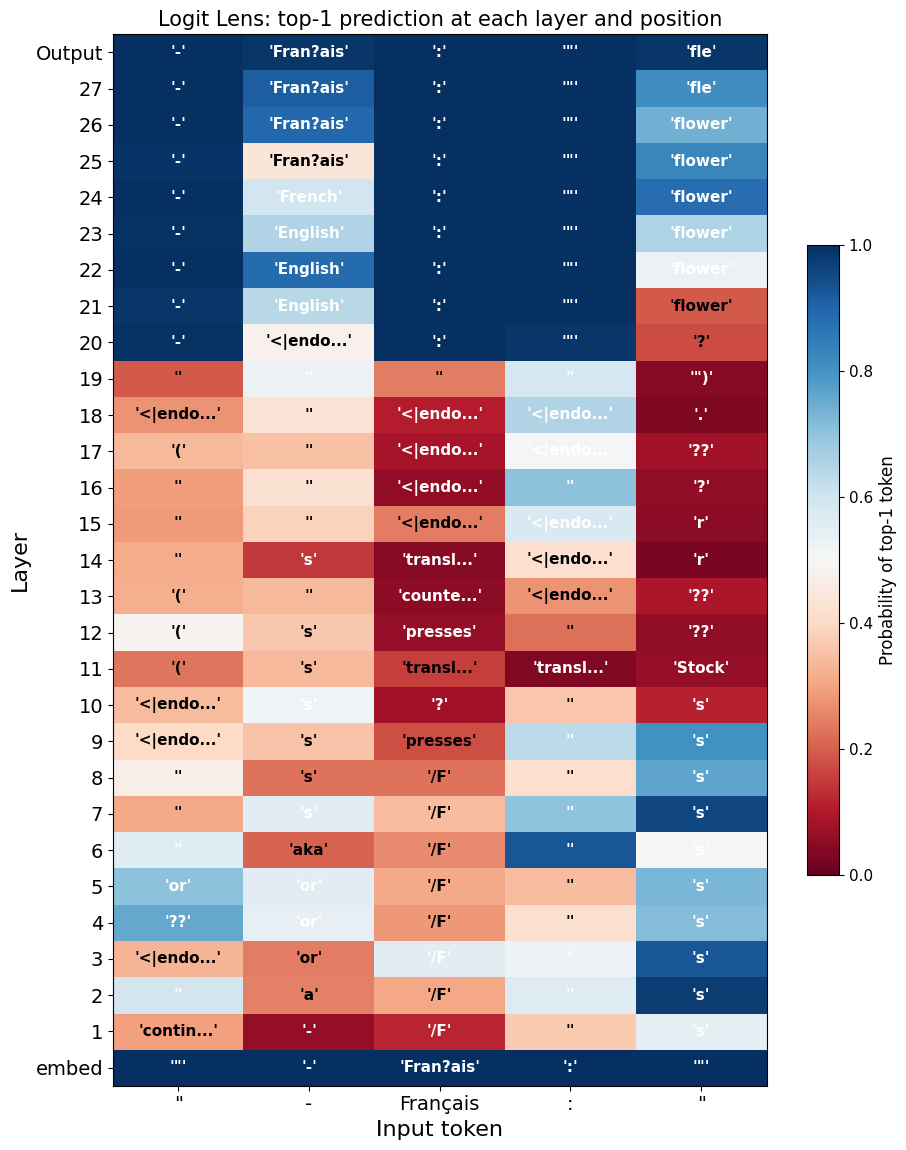

In [ ]:
def logit_lens(model, hidden_states, layer_indices, positions, tokenizer):
    """Core of the logit lens: turn intermediate hidden states into top-1 predictions.

    For each (layer, position) we:
      1. Take the residual stream vector at that layer and position.
      2. Apply the model's final layer norm + unembedding (lm_head) to it.
         This is exactly the projection the model uses at the final layer,
         so we can read off "if the model had to commit to a token right now,
         what would it be?"
      3. Record the top-1 token string and its probability.

    Args:
        model: A causal LM with `.model.norm` (final layer norm) and `.lm_head`
            (the unembedding matrix W_U from Lab 2).
        hidden_states: Tuple of tensors from `model(..., output_hidden_states=True)`.
            Length = n_layers + 1. Index 0 = embedding output, index -1 = final layer.
        layer_indices: Which layers to read out (list of ints).
        positions: Which token positions to read out (iterable of ints).
        tokenizer: Used only to decode token IDs back to strings.

    Returns:
        labels: list of lists of strings, shape (len(layer_indices), len(positions)).
        probs:  numpy array, same shape, with the top-1 probability.
    """
    positions = list(positions)  # make sure we can iterate multiple times
    n_layers = len(hidden_states)

    labels, probs = [], []
    for layer_idx in layer_indices:
        hidden = hidden_states[layer_idx]  # shape: (1, seq_len, d_model)

        # Apply final layer norm + unembedding. The final hidden state has
        # already passed through the norm inside the model, so skip it there
        # to avoid double-normalising.
        if layer_idx == n_layers - 1:
            logits_layer = model.lm_head(hidden)
        else:
            logits_layer = model.lm_head(model.model.norm(hidden))

        # Restrict to the positions we care about, then take top-1 per position.
        logits_at_pos = logits_layer[0, positions]              # (P, vocab)
        probs_at_pos = logits_at_pos.softmax(-1)                # (P, vocab)
        top_ids = logits_at_pos.argmax(-1)                      # (P,)
        top_probs = probs_at_pos.gather(-1, top_ids[:, None])[:, 0]  # (P,)

        row_labels = [tokenizer.decode(i.item()).strip() for i in top_ids]
        labels.append(row_labels)
        probs.append(top_probs.tolist())

    return labels, np.array(probs)


def plot_logit_lens(labels, probs, x_tokens, y_layer_names, title="Logit Lens: top-1 prediction at each layer and position"):
    """Heatmap of the logit-lens probabilities with the predicted token overlaid.

    Args:
        labels: list of lists of token strings, shape (n_layers_shown, n_positions).
        probs:  numpy array of the same shape, values in [0, 1].
        x_tokens: list of strings to label the x-axis (input tokens).
        y_layer_names: list of strings to label the y-axis (layer names).
    """
    n_layers_shown, n_positions = probs.shape

    fig, ax = plt.subplots(figsize=(max(6, n_positions * 1.9), max(8, n_layers_shown * 0.4)))

    # Red = low confidence, blue = high confidence.
    ax.imshow(probs, aspect="auto", cmap=plt.cm.RdBu,
              norm=mcolors.Normalize(vmin=0, vmax=1), origin="lower")

    # Write the predicted token inside each cell.
    for i in range(n_layers_shown):
        for j in range(n_positions):
            # Matplotlib can't render e.g. CJK glyphs from every tokenizer; strip to ASCII.
            tok = labels[i][j].encode("ascii", errors="replace").decode("ascii")
            if len(tok) > 8:
                tok = tok[:6] + "..."
            # Pick a text colour that stays readable against the background.
            color = "white" if probs[i, j] > 0.5 or probs[i, j] < 0.15 else "black"
            ax.text(j, i, repr(tok), ha="center", va="center",
                    fontsize=11, color=color, fontweight="bold")

    ax.set_yticks(range(n_layers_shown))
    ax.set_yticklabels(y_layer_names, fontsize=14)
    ax.set_ylabel("Layer", fontsize=16)

    ax.set_xticks(range(n_positions))
    ax.set_xticklabels(x_tokens, rotation=0, fontsize=14)
    ax.xaxis.set_ticks_position("bottom")
    ax.set_xlabel("Input token", fontsize=16)

    ax.set_title(title, fontsize=15)
    cbar = fig.colorbar(ax.images[0], ax=ax, shrink=0.6)
    cbar.set_label("Probability of top-1 token", fontsize=12)
    cbar.ax.tick_params(labelsize=11)
    plt.tight_layout()
    plt.show()


def logit_lens_heatmap(model, tokenizer, prompt, n_show_tokens=10, n_step=1):
    """Thin wrapper: run the model, pick layers/positions, compute the lens, plot it."""
    # 1. Run the model and ask it to return every intermediate residual stream.
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with t.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    hidden_states = outputs.hidden_states
    n_layers = len(hidden_states)
    print(f"Number of hidden states (embedding + {n_layers - 1} layers): {n_layers}")

    # 2. Decide which layers and token positions to show.
    layer_indices = list(range(0, n_layers, n_step))
    if (n_layers - 1) not in layer_indices:
        layer_indices.append(n_layers - 1)
    input_ids = inputs["input_ids"][0]
    positions = list(range(max(0, len(input_ids) - n_show_tokens), len(input_ids)))

    # 3. Run the lens.
    labels, probs = logit_lens(model, hidden_states, layer_indices, positions, tokenizer)

    # 4. Build human-readable axis labels and plot.
    y_names = ["embed" if i == 0 else "Output" if i == n_layers - 1 else str(i)
               for i in layer_indices]
    x_tokens = [tokenizer.decode(input_ids[p].item()).strip() or "▁" for p in positions]
    plot_logit_lens(labels, probs, x_tokens, y_names)


logit_lens_heatmap(model, tokenizer, prompt, n_show_tokens=5, n_step=1)


## Interpreting the results

If the model follows the pattern described in the paper, you should see something like:

- **Early layers** (0–5): noisy predictions, often common tokens or fragments.
- **Late Middle layers** (around 21-26): the model starts predicting the English translation (`"flower"`, `"blossom"`, etc.), even though the few-shot task requires the French word. This suggests the model routes through English to represent its information. The paper argues that models think in `"input space" -> "concept space" -> "output space"`.
- **Late layers** (final 2): the prediction shifts to the correct French token (`" fle"`).

The effect is clearer with larger models, so the 0.5B model used earlier will show a weaker or noisier version of this pattern. The paper uses much larger Llama models where the English pivot is very pronounced. But even with a small model, the general principle holds: intermediate layers often represent meaning in a different form than what eventually appears in the output.

This connects directly to the **residual stream** concept from Lab 2: the model gradually builds up its answer layer by layer, and the logit lens lets us observe this process.

Disclaimer:
- We also see a lot of noise, many of the 'predicted' intermetiate tokens are not very interpretable (e.g. a lot of punctuation marks, and end end of text tokens).
- We have to be carefull not to interpret the results too quickly, it's very easy to form a theory based on your observations that might be very flawed. To really understand it we have to run it for a ton of variations and test our predictions a lot. The key mantra in MechInterp (and good research in general), is **try to fail fast**, that is, if you have a theory, figure out what could disprove it the quickest so you don't waste too much time trying really hard to convince yourself that you found something.


## Cleanup


In [ ]:
# To prevent auto clean up, in case you want to play with it, we create a stop here.
raise InterruptedError("Stopping here — re-run cells below manually when ready.")

In [ ]:
cleanup("model", "tokenizer")

model: 494M params
Cleanup done.


---

> ## Key takeaways
>
> - Chat/instruct models are just next-token predictors trained on data with special formatting tokens. The `apply_chat_template` method reveals this formatting.
> - BERT uses bidirectional attention (no causal mask), which is better suited for understanding tasks like classification. GPT uses causal attention, which is better suited for generation.
> - The HuggingFace `Trainer` API abstracts away the training loop we wrote by hand in Lab 2, making fine-tuning practical with minimal code.
> - The logit lens lets us inspect what a model is "thinking" at intermediate layers by applying the unembedding matrix at each layer. Multilingual models often route through English internally, even when translating between two non-English languages.
